In [11]:
# Install only what we need
!pip install -q gradio
print("Done ")

Done 


In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

print("TensorFlow:", tf.__version__)
print(" All good!")

TensorFlow: 2.20.0
 All good!


In [13]:
# Direct Keras MNIST
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print(" Data loaded!")
print("Train:", x_train.shape)
print("Test:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
 Data loaded!
Train: (60000, 28, 28)
Test: (10000, 28, 28)


In [14]:
# Data preprocess
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Shape reshape(CNN)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# Labels
num_classes = 10
y_train_cat = keras.utils.to_categorical(y_train, num_classes)
y_test_cat = keras.utils.to_categorical(y_test, num_classes)

print(" Preprocessing done!")
print(f"Train shape: {x_train.shape}")
print(f"Test shape: {x_test.shape}")
print(f"Classes: {num_classes} (0-9 digits)")

 Preprocessing done!
Train shape: (60000, 28, 28, 1)
Test shape: (10000, 28, 28, 1)
Classes: 10 (0-9 digits)


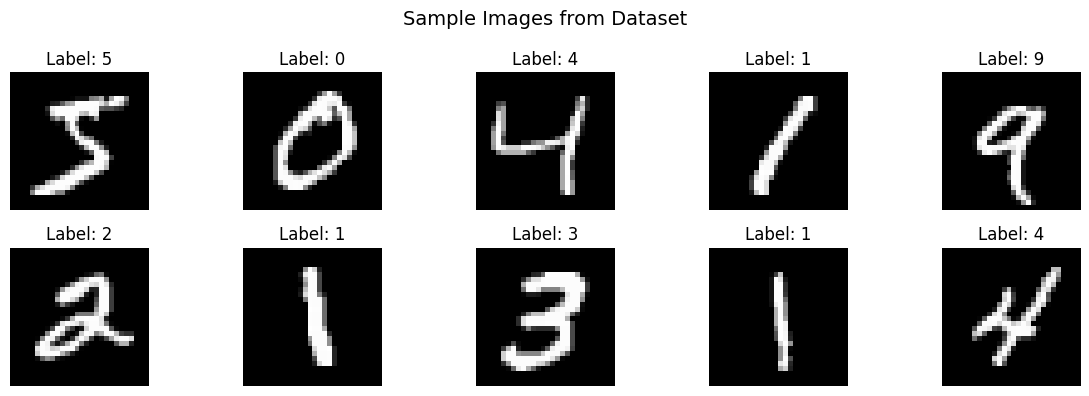

Samples shown!


In [15]:
# Dataset samples
class_names = ['0','1','2','3','4','5','6','7','8','9']
plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {class_names[y_train[i]]}")
    plt.axis('off')
plt.suptitle('Sample Images from Dataset', fontsize=14)
plt.tight_layout()
plt.show()
print("Samples shown!")

In [16]:
# CNN Model Architecture
model = keras.Sequential([
    # Block 1
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    # Block 2
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    # Block 3  Fully Connected
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    # Output
    layers.Dense(10, activation='softmax')
])

model.summary()
print(" Model ready!")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 10, 10, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 10, 10, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 362,986 (1.38 MB)

 Trainable params: 362,282 (1.38 MB)

 Non-trainable params: 704 (2.75 KB)

 Model ready!


In [17]:
# Model compile
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks best model save
callbacks = [
    keras.callbacks.ModelCheckpoint(
        'best_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    )
]

print(" Model compiled!")
print("Optimizer: Adam")
print("Loss: Categorical Crossentropy")

 Model compiled!
Optimizer: Adam
Loss: Categorical Crossentropy


In [18]:
# Model training
print("Training starts..")
print("(It willtake 5-10 minutes..)")
print(" " * 50)

history = model.fit(
    x_train, y_train_cat,
    batch_size=128,
    epochs=20,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

print(" " * 50)
print(" Training complete!")

Training starts..
(It willtake 5-10 minutes..)
                                                  
Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step - accuracy: 0.7575 - loss: 0.8012
Epoch 1: val_accuracy improved from None to 0.72383, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
422/422 ━━━━━━━━━━━━━━━━━━━━ 170s 379ms/step - accuracy: 0.8869 - loss: 0.3655 - val_accuracy: 0.7238 - val_loss: 0.8578 - learning_rate: 0.0010
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step - accuracy: 0.9671 - loss: 0.1090
Epoch 2: val_accuracy improved from 0.72383 to 0.98750, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
422/422 ━━━━━━━━━━━━━━━━━━━━ 195s 364ms/step - accuracy: 0.9700 - loss: 0.0995 - val_accuracy: 0.9875 - val_loss: 0.0429 - learning_rate: 0.0010
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - accuracy: 0.9755 - loss: 0.0819
Epoch 3: val_accuracy improved from 0.98750 to 0.99200, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
422/422 ━━━━━━━━━━━━━━━━━━━━ 154s 365ms/step - accuracy: 0.9766 - loss: 0.0786 - val_accuracy: 0.9920 - val_loss: 0.0284 - learning_rate: 0.0010
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - accuracy: 0.9811 - loss: 0.0610
Epoch 4: val_accuracy did not improve from 0.99200
422/422 ━━━━━━━━━━━━━━━━━━━━ 153s 362ms/step - accuracy: 0.9815 - loss: 0.0613 - val_accuracy: 0.9917 - val_loss: 0.0265 - learning_rate: 0.0010
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - accuracy: 0.9848 - loss: 0.0507
Epoch 5: val_accuracy did not improve from 0.99200
422/422 ━━━━━━━━━━━━━━━━━━━━ 201s 360ms/step - accuracy: 0.9843 - loss: 0.0527 - val_accuracy: 0.9907 - val_loss: 0.0359 - learning_rate: 0.0010
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - accuracy: 0.9856 - loss: 0.0500
Epoch 6: val_accuracy improved from 0.99200 to 0.99267, saving model to best_model.h5



Epoch 6: finished saving model to best_model.h5
422/422 ━━━━━━━━━━━━━━━━━━━━ 205s 369ms/step - accuracy: 0.9860 - loss: 0.0492 - val_accuracy: 0.9927 - val_loss: 0.0234 - learning_rate: 0.0010
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step - accuracy: 0.9876 - loss: 0.0430
Epoch 7: val_accuracy improved from 0.99267 to 0.99283, saving model to best_model.h5



Epoch 7: finished saving model to best_model.h5
422/422 ━━━━━━━━━━━━━━━━━━━━ 156s 369ms/step - accuracy: 0.9875 - loss: 0.0421 - val_accuracy: 0.9928 - val_loss: 0.0254 - learning_rate: 0.0010
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step - accuracy: 0.9876 - loss: 0.0394
Epoch 8: val_accuracy did not improve from 0.99283
422/422 ━━━━━━━━━━━━━━━━━━━━ 155s 367ms/step - accuracy: 0.9877 - loss: 0.0399 - val_accuracy: 0.9923 - val_loss: 0.0327 - learning_rate: 0.0010
Epoch 9/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - accuracy: 0.9888 - loss: 0.0379
Epoch 9: val_accuracy did not improve from 0.99283

Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
422/422 ━━━━━━━━━━━━━━━━━━━━ 202s 368ms/step - accuracy: 0.9891 - loss: 0.0369 - val_accuracy: 0.9922 - val_loss: 0.0277 - learning_rate: 0.0010
Epoch 10/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step - accuracy: 0.9915 - loss: 0.0284
Epoch 10: val_accuracy improved from 0.99283 to 0.99433, saving model to


Epoch 10: finished saving model to best_model.h5
422/422 ━━━━━━━━━━━━━━━━━━━━ 156s 369ms/step - accuracy: 0.9921 - loss: 0.0268 - val_accuracy: 0.9943 - val_loss: 0.0219 - learning_rate: 5.0000e-04
Epoch 11/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - accuracy: 0.9937 - loss: 0.0221
Epoch 11: val_accuracy did not improve from 0.99433
422/422 ━━━━━━━━━━━━━━━━━━━━ 201s 367ms/step - accuracy: 0.9934 - loss: 0.0223 - val_accuracy: 0.9942 - val_loss: 0.0224 - learning_rate: 5.0000e-04
Epoch 12/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - accuracy: 0.9933 - loss: 0.0216
Epoch 12: val_accuracy improved from 0.99433 to 0.99467, saving model to best_model.h5



Epoch 12: finished saving model to best_model.h5
422/422 ━━━━━━━━━━━━━━━━━━━━ 156s 369ms/step - accuracy: 0.9930 - loss: 0.0231 - val_accuracy: 0.9947 - val_loss: 0.0222 - learning_rate: 5.0000e-04
Epoch 13/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step - accuracy: 0.9942 - loss: 0.0190
Epoch 13: val_accuracy improved from 0.99467 to 0.99550, saving model to best_model.h5



Epoch 13: finished saving model to best_model.h5

Epoch 13: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
422/422 ━━━━━━━━━━━━━━━━━━━━ 203s 372ms/step - accuracy: 0.9935 - loss: 0.0208 - val_accuracy: 0.9955 - val_loss: 0.0228 - learning_rate: 5.0000e-04
Epoch 14/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - accuracy: 0.9942 - loss: 0.0179
Epoch 14: val_accuracy did not improve from 0.99550
422/422 ━━━━━━━━━━━━━━━━━━━━ 202s 371ms/step - accuracy: 0.9942 - loss: 0.0185 - val_accuracy: 0.9950 - val_loss: 0.0199 - learning_rate: 2.5000e-04
Epoch 15/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step - accuracy: 0.9951 - loss: 0.0156
Epoch 15: val_accuracy did not improve from 0.99550
422/422 ━━━━━━━━━━━━━━━━━━━━ 200s 368ms/step - accuracy: 0.9949 - loss: 0.0163 - val_accuracy: 0.9948 - val_loss: 0.0213 - learning_rate: 2.5000e-04
Epoch 16/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step - accuracy: 0.9951 - loss: 0.0157
Epoch 16: val_accuracy did not improve from 0.99550
42


Epoch 17: finished saving model to best_model.h5
422/422 ━━━━━━━━━━━━━━━━━━━━ 199s 364ms/step - accuracy: 0.9953 - loss: 0.0139 - val_accuracy: 0.9960 - val_loss: 0.0193 - learning_rate: 2.5000e-04
Epoch 18/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - accuracy: 0.9959 - loss: 0.0127
Epoch 18: val_accuracy did not improve from 0.99600
422/422 ━━━━━━━━━━━━━━━━━━━━ 153s 362ms/step - accuracy: 0.9955 - loss: 0.0136 - val_accuracy: 0.9950 - val_loss: 0.0214 - learning_rate: 2.5000e-04
Epoch 19/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step - accuracy: 0.9966 - loss: 0.0120
Epoch 19: val_accuracy did not improve from 0.99600
422/422 ━━━━━━━━━━━━━━━━━━━━ 155s 366ms/step - accuracy: 0.9960 - loss: 0.0137 - val_accuracy: 0.9952 - val_loss: 0.0202 - learning_rate: 2.5000e-04
Epoch 20/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step - accuracy: 0.9966 - loss: 0.0116
Epoch 20: val_accuracy did not improve from 0.99600

Epoch 20: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
42

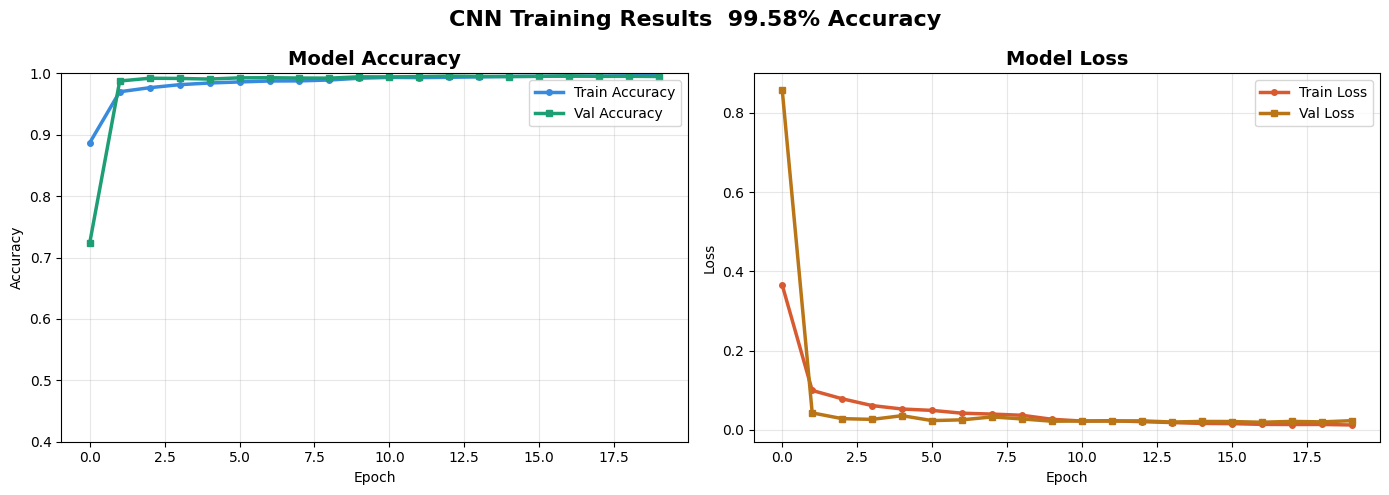

Graphs saved!


In [19]:
# Training graphs
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy Graph
axes[0].plot(history.history['accuracy'],
             color='#378ADD', linewidth=2.5, marker='o',
             markersize=4, label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'],
             color='#1D9E75', linewidth=2.5, marker='s',
             markersize=4, label='Val Accuracy')
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0.4, 1.0])

# Loss Graph
axes[1].plot(history.history['loss'],
             color='#D85A30', linewidth=2.5, marker='o',
             markersize=4, label='Train Loss')
axes[1].plot(history.history['val_loss'],
             color='#BA7517', linewidth=2.5, marker='s',
             markersize=4, label='Val Loss')
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('CNN Training Results  99.58% Accuracy',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('training_graphs.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphs saved!")

In [20]:
# Best model reload
model.load_weights('best_model.h5')
print(" Best weights loaded!")

# Ab dobara evaluate karo
test_loss, test_accuracy = model.evaluate(x_test, y_test_cat, verbose=0)
print(f" Test Accuracy: {test_accuracy*100:.2f}%")

# Predictions
y_pred = model.predict(x_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = y_test

print(f"\nUnique predictions: {np.unique(y_pred_classes)}")
print(f"Prediction distribution: {np.bincount(y_pred_classes)}")

 Best weights loaded!
 Test Accuracy: 99.51%

Unique predictions: [0 1 2 3 4 5 6 7 8 9]
Prediction distribution: [ 982 1141 1026 1011  982  891  957 1030  973 1007]


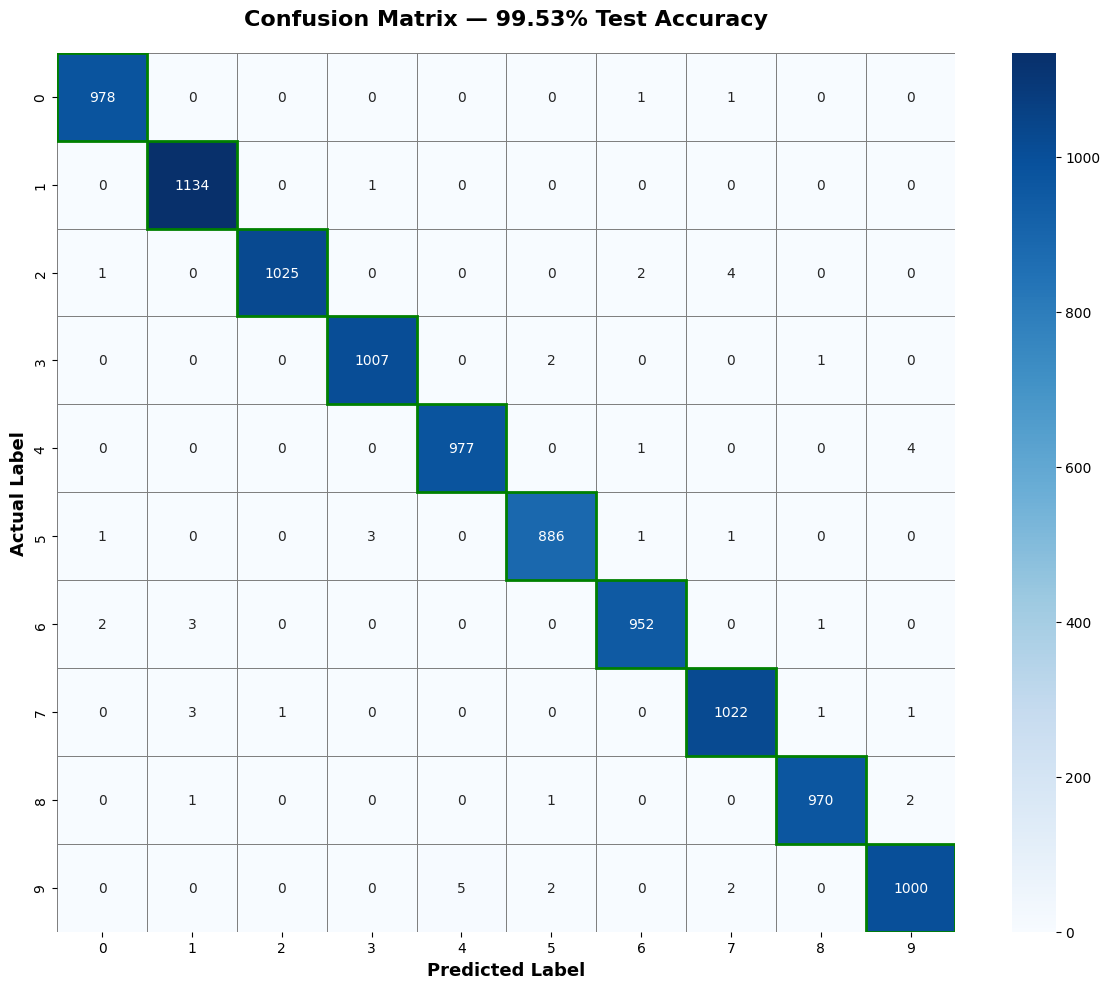

 Confusion Matrix saved!

 Classification Report:
                                                       
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       980
           1       0.99      1.00      1.00      1135
           2       1.00      0.99      1.00      1032
           3       1.00      1.00      1.00      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       1.00      1.00      1.00       974
           9       0.99      0.99      0.99      1009

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



In [21]:
# Confusion Matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(12, 10))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            linewidths=0.5,
            linecolor='gray')

# Diagonal highlight
for i in range(len(class_names)):
    plt.gca().add_patch(plt.Rectangle((i, i), 1, 1,
                        fill=False, edgecolor='green', lw=2))

plt.title('Confusion Matrix — 99.53% Test Accuracy',
          fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Actual Label', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Confusion Matrix saved!")

# Classification Report print
print("\n Classification Report:")
print(" "*55)
print(classification_report(y_true_classes, y_pred_classes,
                            target_names=class_names))

In [22]:
# Gradio installation
!pip install gradio -q
print(" Gradio ready!")

 Gradio ready!


In [ ]:
import gradio as gr

def predict_digit(image):
    if image is None:
        return "Draw a digit first!"

    img = image['composite'] if isinstance(image, dict) else image
    img = np.array(img, dtype=np.float32)

    if len(img.shape) == 3:
        img = np.mean(img[:,:,:3], axis=2)

    import cv2
    img = cv2.resize(img, (28, 28))
    img = 255.0 - img

    img = img / 255.0
    img = img.reshape(1, 28, 28, 1)

    predictions = model.predict(img, verbose=0)[0]

    top3_idx = np.argsort(predictions)[::-1][:3]
    result = {}
    for idx in top3_idx:
        result[str(idx)] = float(predictions[idx])

    return result

demo2 = gr.Interface(
    fn=predict_digit,
    inputs=gr.Sketchpad(
        label=" Draw digit  (0-9)",
        type="numpy"
    ),
    outputs=gr.Label(
        num_top_classes=3,
        label=" Prediction"
    ),
    title=" Handwritten Digit Recognition",
    description="Draw any digit on canvas (0-9)!",
    theme=gr.themes.Soft()
)

demo2.launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://a7c75733d31c6e1d4b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
if 'demo2' in globals():
    demo2.close()
    print(" Gradio closed!")
else:
    print("Warning: Gradio interface 'demo2' was not found. Please ensure the cell defining 'demo2' (e.g., cell I3BTZaSgY_cz) has been executed.")

In [ ]:
if 'model' in globals():
    model.save('handwritten_digit_recognition.keras')
    print(" Model saved!")
else:
    print("Warning: The 'model' object is not defined. Please ensure the cells defining and training the model (e.g., IhYr-h5dPqO_ to Iu2UG9zVWnjW) have been executed.")

In [ ]:
from google.colab import files
files.download('best_model.h5')
files.download('training_graphs.png')
files.download('confusion_matrix.png')
print("✅ All files downloaded!")